# 18장 실습 — 월드 모델은 시뮬레이터를 대체하는가

이 책은 열일곱 장 동안 시뮬레이터를 다뤘다. 고치고(4·5장), 덮고(6·7장), 채점하고(3장), 데이터 공장으로 쓰고(4부), 실기로 넘기는 절차를 세웠다(16·17장).

마지막 질문은 그 전제 자체를 겨눈다. **손으로 만든 시뮬레이터가 꼭 있어야 하는가.** 데이터에서 동역학을 배워 그것을 시뮬레이터 자리에 놓으면 안 되는가. 물리 엔진을 맞추느라 4장과 5장에서 한 고생이 통째로 사라질 수도 있는 이야기다.

이 노트북은 그 질문에 숫자로 답한다. 학습된 동역학 모델을 세우고, 얼마나 멀리까지 믿을 수 있는지 재고, **시뮬레이터가 실제로 하는 일 — 정책을 고르는 일 — 을 대신할 수 있는지**까지 확인한다.

실행 시간은 CPU에서 5분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 환경은 16장 것을 그대로 쓴다

교란 손잡이가 붙어 있는 16장의 환경이다. 이 노트북에서는 교란을 끄고 공칭 조건만 쓴다 — 여기서 겨루는 것은 시뮬과 실기가 아니라 **손으로 만든 시뮬과 배운 시뮬**이기 때문이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="{integ}" cone="{cone}"
          iterations="{iters}"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MU, KV = .60, 120.
NOMINAL = dict(integ="implicitfast", cone="pyramidal", iters=100)
CACHE = {}


def model_of(mu, kv, integ, cone, iters):
    k = (round(mu, 2), round(kv, 0), integ, cone, iters)
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(
            XML.format(mu=k[0], kv=k[1], integ=integ, cone=cone,
                       iters=iters))
    return CACHE[k]


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def expert(b, p, g):
    dv = unit(g - b)
    if np.linalg.norm(g - b) < .012:
        return np.zeros(2)
    e = (b - dv * .045) - p
    if np.linalg.norm(e) > .013:
        u = 14. * e
        n = np.linalg.norm(u)
        return u / n * .22 if n > .22 else u
    return dv * .22


class Vec:
    def __init__(self, n, seed=0, mu=MU, kv=KV, lat=0, noise=0.,
                 bias=(0., 0.), quant=0, rate=0., **eng):
        e = dict(NOMINAL, **eng)
        self.m = model_of(mu, kv, e["integ"], e["cone"], e["iters"])
        self.sub = int(round(1 / 20 / self.m.opt.timestep))
        self.n, self.lat, self.noise = n, lat, noise
        self.quant, self.rate = quant, rate
        self.bias = np.asarray(bias)
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.buf = [None] * n
        self.prev = np.zeros((n, 2))
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
        self.buf[i] = [np.zeros(2)] * (self.lat + 1)
        self.prev[i] = 0.

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float) + self.bias
            if self.noise:
                b = b + self.rng.normal(0, self.noise, 2)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def shape(self, i, a):
        # 구동기가 실제로 받는 명령 — 양자화와 변화율 제한
        u = np.clip(a, -1, 1) * AMAX
        if self.quant:
            step = 2 * AMAX / self.quant
            u = np.round(u / step) * step
        if self.rate:
            d = np.clip(u - self.prev[i], -self.rate, self.rate)
            u = self.prev[i] + d
        self.prev[i] = u
        return u

    def step(self, a, keep=None):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            self.buf[i].append(self.shape(i, a[i]))
            d.ctrl[:] = self.buf[i][-1 - self.lat]
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3, **kw):
    torch.manual_seed(seed)
    env = Vec(n, seed, **kw)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


class BCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


def collect_bc(n_ep=200, seed=1, **kw):
    env = Vec(8, seed, **kw)
    X, Y = [], []
    for _ in range(n_ep * EP // 8):
        o = env.obs()
        acts = []
        for i, d in enumerate(env.d):
            b = np.asarray(d.qpos[0:2], float)
            acts.append(expert(b, np.asarray(d.qpos[7:9], float),
                               env.g[i]) / AMAX)
        acts = np.array(acts, np.float32)
        X.append(o)
        Y.append(acts)
        env.step(acts)
    return np.concatenate(X), np.concatenate(Y)


def train_bc(X, Y, seed=0, epochs=150):
    torch.manual_seed(seed)
    net = BCNet()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 256):
            j = idx[k:k + 256]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


def score(pol, n=150, seed=999, **kw):
    kind, net = pol
    torch.manual_seed(seed)
    env = Vec(8, seed, **kw)
    got = []
    while len(got) < n:
        o = torch.from_numpy(env.obs())
        with torch.no_grad():
            if kind == "rl":
                u = net.dist(o).sample().numpy()
            else:
                u = net(o).numpy()
        got += env.step(u)[2]
    return float(np.mean(got[:n]))

## 정책 넷과 전이 데이터

동역학 모델을 배우려면 데이터가 필요하고, 그 데이터는 **어떤 정책이 굴려서 모은 것**이다. 이 사실이 이 노트북의 결말을 정한다.

16장의 후보 넷을 그대로 쓴다. 셋으로 데이터를 모아 모델을 학습시키고, **하나는 남겨 둔다.**

In [5]:
t0 = time.time()
POL = {}
POL["RL 씨앗0"] = ("rl", train_rl(seed=0))
POL["RL 씨앗1"] = ("rl", train_rl(seed=1))
POL["모방"] = ("bc", train_bc(*collect_bc()))
POL["모방+증강"] = ("bc", train_bc(*collect_bc(noise=.003)))
print(f"정책 넷 준비 끝  ({time.time()-t0:.0f}s)")

HELD = "모방+증강"
TRAIN_POL = [k for k in POL if k != HELD]


def act(pol, o):
    kind, net = pol
    with torch.no_grad():
        if kind == "rl":
            return net.dist(o).sample().numpy()
        return net(o).numpy()


def transitions(pol, rounds=140, seed=3):
    # (관측, 행동, 다음 관측) 을 모은다
    env = Vec(16, seed)
    O, A, O2 = [], [], []
    for _ in range(rounds):
        o = env.obs()
        u = act(pol, torch.from_numpy(o))
        env.step(u)
        o2 = env.obs()
        keep = env.t > 0          # 초기화 직후 쌍은 버린다
        O.append(o[keep])
        A.append(np.clip(u, -1, 1)[keep])
        O2.append(o2[keep])
    return (np.concatenate(O), np.concatenate(A).astype(np.float32),
            np.concatenate(O2))


data = {k: transitions(POL[k], seed=3 + i)
        for i, k in enumerate(POL)}
Xtr = np.concatenate([np.hstack([data[k][0], data[k][1]])
                      for k in TRAIN_POL])
Ytr = np.concatenate([data[k][2] - data[k][0] for k in TRAIN_POL])
print(f"학습 전이 {len(Xtr):,}쌍  ({time.time()-t0:.0f}s)")

정책 넷 준비 끝  (124s)


학습 전이 6,672쌍  (126s)


## 동역학 모델

관측과 행동을 받아 **관측의 변화량**을 내놓는 MLP다. 변화량을 배우게 하는 것은 이 계열의 관행인데, 한 스텝 사이에 관측이 크게 변하지 않으니 그 편이 배우기 쉽다.

In [6]:
class Dyn(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(10, 128), nn.Tanh(),
                               nn.Linear(128, 128), nn.Tanh(),
                               nn.Linear(128, 8))

    def forward(self, x):
        return self.f(x)


def train_dyn(X, Y, seed=0, epochs=40):
    torch.manual_seed(seed)
    net = Dyn()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 512):
            j = idx[k:k + 512]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


dyn = train_dyn(Xtr, Ytr)
with torch.no_grad():
    e1 = dyn(torch.from_numpy(Xtr)) - torch.from_numpy(Ytr)
    pos = float((e1[:, 0:2] ** 2).sum(1).mean().sqrt()) / 10 * 1000
print(f"한 스텝 블록 위치 예측 오차 {pos:.2f} mm"
      f"  ({time.time()-t0:.0f}s)")

한 스텝 블록 위치 예측 오차 2.21 mm  (126s)


## 얼마나 멀리까지 믿을 수 있는가

한 스텝 오차는 작다. 문제는 시뮬레이터로 쓰려면 **여러 스텝을 이어 붙여야** 한다는 것이다. 자기 예측 위에 다시 예측을 쌓으면 오차도 함께 쌓인다.

진짜 환경과 배운 모델을 같은 초기 상태에서 같은 정책으로 굴리고, 블록 위치의 차이가 지평에 따라 어떻게 벌어지는지 본다.

In [7]:
def divergence(pol, H=60, n=40, seed=77):
    env = Vec(n, seed)
    o = env.obs()
    oh = o.copy()
    errs = []
    for t in range(H):
        u = act(pol, torch.from_numpy(o))
        uh = act(pol, torch.from_numpy(oh))
        env.step(u)
        with torch.no_grad():
            uc = np.clip(uh, -1, 1).astype(np.float32)
            x = np.hstack([oh, uc])
            oh = oh + dyn(torch.from_numpy(x)).numpy()
        o = env.obs()
        e = np.abs(oh[:, 0:2] - o[:, 0:2]).mean()
        errs.append(e / 10 * 1000)
    return np.array(errs)


HS = (1, 5, 10, 20, 40, 60)
print(pad("정책", 16) + "".join(pad(f"{h}스텝", 10, True)
                                for h in HS))
dv = {}
for k in POL:
    d = divergence(POL[k])
    dv[k] = d
    mark = " (남겨 둔 정책)" if k == HELD else ""
    print(pad(k + mark, 16)
          + "".join(pad(f"{d[h-1]:.0f}", 10, True) for h in HS))
print("\n단위는 mm — 배운 모델이 예측한 블록 위치와 진짜의 차이")

정책                 1스텝     5스텝    10스텝    20스텝    40스텝    60스텝


RL 씨앗0                 0         6        11        27        19        26


RL 씨앗1                 1         9        15        19        17        25


모방                     0         7        27        47        66        60


모방+증강 (남겨 둔 정책)         1         5        23        71       189       378

단위는 mm — 배운 모델이 예측한 블록 위치와 진짜의 차이


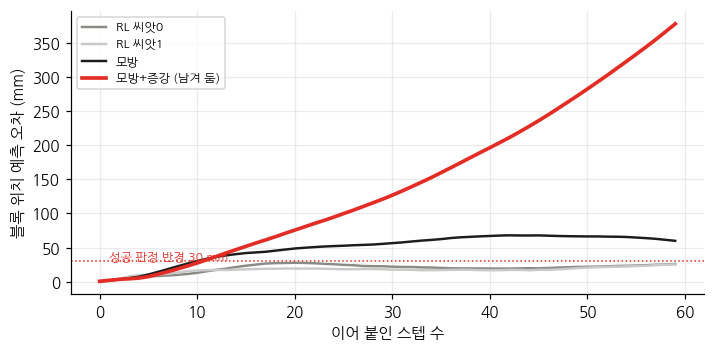

In [8]:
fig, ax = plt.subplots(figsize=(6.6, 3.3))
for k, c in zip(POL, (GREY, "#C9C9C9", INK, RED)):
    lw = 2.4 if k == HELD else 1.6
    ax.plot(dv[k], color=c, lw=lw, label=k + (" (남겨 둠)"
                                              if k == HELD else ""))
ax.axhline(30, color=RED, lw=1, ls=":")
ax.text(1, 32, "성공 판정 반경 30 mm", fontsize=8, color=RED)
ax.set_xlabel("이어 붙인 스텝 수")
ax.set_ylabel("블록 위치 예측 오차 (mm)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 정책을 고를 수 있는가

예측 오차는 대리 지표다. 시뮬레이터가 실제로 하는 일은 3장에서 정한 대로 **고르는 것**이다.

고르려면 후보에 실력 차가 있어야 한다. 앞의 정책 넷은 공칭 조건에서 다 잘해서 순위를 논하기 어렵다. 그래서 같은 정책의 행동 크기를 줄인 판본을 섞어 **여섯 후보**를 만든다. 명령을 절반만 내는 정책은 블록을 덜 밀고, 그만큼 성적이 낮다.

채점 지표는 성공률 대신 **블록이 목표 쪽으로 간 거리**로 둔다. 짧은 지평에서도 정의되는 값이라 지평을 바꿔 가며 견주기에 알맞다.

In [9]:
def scaled(pol, g):
    kind, net = pol
    if kind == "rl":
        return ("fn", lambda o: net.dist(o).sample().numpy() * g)
    return ("fn", lambda o: net(o).numpy() * g)


CAND = {}
for base in ("RL 씨앗0", "모방"):
    for g in (.4, .7, 1.):
        CAND[f"{base} ×{g:g}"] = scaled(POL[base], g)


def act2(pol, o):
    kind, f = pol
    if kind == "fn":
        with torch.no_grad():
            return f(o)
    return act(pol, o)


def progress_true(pol, H, n=60, seed=91):
    env = Vec(n, seed)
    d0 = env.db.copy()
    for _ in range(H):
        env.step(act2(pol, torch.from_numpy(env.obs())))
    return float(np.mean(d0 - env.db))


def progress_model(pol, H, n=60, seed=91):
    env = Vec(n, seed)
    oh = env.obs().copy()
    d0 = np.linalg.norm(oh[:, 0:2], axis=1) / 10
    for _ in range(H):
        u = act2(pol, torch.from_numpy(oh))
        with torch.no_grad():
            uc = np.clip(u, -1, 1).astype(np.float32)
            x = torch.from_numpy(np.hstack([oh, uc]))
            oh = oh + dyn(x).numpy()
    d1 = np.linalg.norm(oh[:, 0:2], axis=1) / 10
    return float(np.mean(d0 - d1))


def mmrv(pred, real):
    pred, real = np.asarray(pred), np.asarray(real)
    out = []
    for i in range(len(pred)):
        v = [abs(real[i] - real[j])
             for j in range(len(pred))
             if (pred[i] - pred[j]) * (real[i] - real[j]) < 0]
        out.append(max(v) if v else 0.)
    return float(np.mean(out))


print(pad("지평", 10) + pad("MMRV ↓ (mm)", 14, True)
      + pad("Pearson r ↑", 14, True))
keep = {}
for H in (10, 25, 50, 100):
    tr = [progress_true(CAND[k], H) for k in CAND]
    md = [progress_model(CAND[k], H) for k in CAND]
    keep[H] = (tr, md)
    r = float(np.corrcoef(md, tr)[0, 1])
    print(pad(f"{H}스텝", 10)
          + pad(f"{mmrv(md, tr)*1000:.1f}", 14, True)
          + pad(f"{r:.2f}", 14, True))

print()
tr, md = keep[25]
print(pad("후보 (25스텝)", 18) + pad("진짜 전진", 12, True)
      + pad("모델 추정", 12, True))
for k, x, y in zip(CAND, tr, md):
    print(pad(k, 18) + pad(f"{x*1000:.0f} mm", 12, True)
          + pad(f"{y*1000:.0f} mm", 12, True))

지평         MMRV ↓ (mm)   Pearson r ↑


10스텝               2.6          0.98


25스텝               6.7          0.97


50스텝               1.7          0.96


100스텝              7.5          0.80

후보 (25스텝)        진짜 전진   모델 추정
RL 씨앗0 ×0.4           119 mm       87 mm
RL 씨앗0 ×0.7           197 mm      176 mm
RL 씨앗0 ×1             215 mm      201 mm
모방 ×0.4                52 mm      -24 mm
모방 ×0.7               106 mm       24 mm
모방 ×1                 139 mm       56 mm


## 그런데 반대 방향의 논거도 있다

그렇다고 이 방향이 틀린 것은 아니다. 2026년에 나온 문제 제기 하나가 정확히 반대쪽을 겨눈다 — **강화학습 도중 정책은 계속 변하는데 시뮬레이터는 고정돼 있다**는 것이다. 학습이 진행되면 정책이 지나가는 자리가 달라지고, 고정된 시뮬레이터가 그 자리에서 맞는다는 보장은 처음 맞춰 둔 자리에서만큼 강하지 않다.

이 관점에서 보면 위 실험의 결과가 다르게 읽힌다. 배운 모델이 「자기가 본 정책에 대해서만 맞는다」는 것은 약점인 동시에 **갱신할 수 있다는 뜻**이기도 하다. 정책이 변하면 모델도 새 데이터로 따라 움직일 수 있다. 물리 엔진은 그렇게 못 한다 — 4장에서 본 대로 다시 식별하는 데 전용 실험이 필요하다.

> 이 대목에서 용어를 조심할 필요가 있다. 최근의 월드 모델 연구 중 상당수는 **시뮬레이터를 대체하겠다고 주장하지 않는다.** 계획과 상상을 위한 잠재 동역학을 다루는 계열과, 물리 시뮬레이터의 자리를 놓고 다투는 계열은 목표가 다르다. 논문을 읽을 때 「무엇을 대체하려는가」를 먼저 확인하는 편이 좋다.

## 정리

**한 스텝은 정확한데 이어 붙이면 무너진다.** 자기 예측 위에 예측을 쌓으면 오차가 함께 쌓이고, 이 과제의 에피소드 길이에 이르기 전에 성공 판정 반경을 넘어선다.

**배운 모델은 자기가 본 정책의 궤적 주변에서만 맞는다.** 남겨 둔 정책에서 오차가 더 컸다. 물리 엔진이 정책과 무관하다는 것이 값이다.

**그런데 고르는 일은 생각보다 잘한다.** 절대 오차가 성공 반경을 넘긴 지평에서도 여섯 후보의 순위 상관은 0.8대였다. 3장에서 값이 아니라 순위를 보라고 한 이유가 여기서도 작동한다.

**문제는 고르는 일이 본 적 없는 후보를 평가하는 일이라는 것이다.** 배운 모델이 가장 약한 자리가 바로 거기다.

**그래도 방향이 틀린 것은 아니다.** 정책이 변하면 모델도 따라 움직일 수 있다는 것은 고정된 시뮬레이터에 없는 성질이고, 그 점을 지적하는 논거가 이미 나와 있다.

이 책이 여기서 끝난다. 열여덟 장 동안 만든 것은 기법의 목록이라기보다 **재는 법과 고르는 법**이었다. 남은 것은 못 푼 것들인데, 그것을 적는 일은 본문의 마지막 절이 맡는다.